In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("C:\\Users\\simra\\OneDrive\\Desktop\\DataAnalytics_L2_House_Price_Prediction\\House Price Prediction Dataset.csv")


In [8]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [10]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [11]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


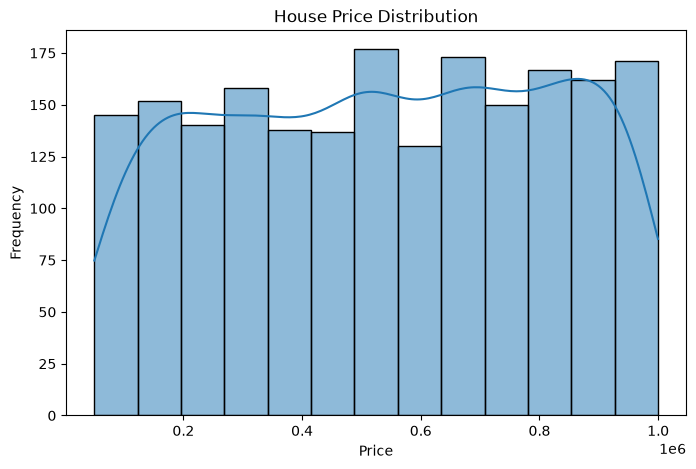

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Price'],
    kde=True
)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

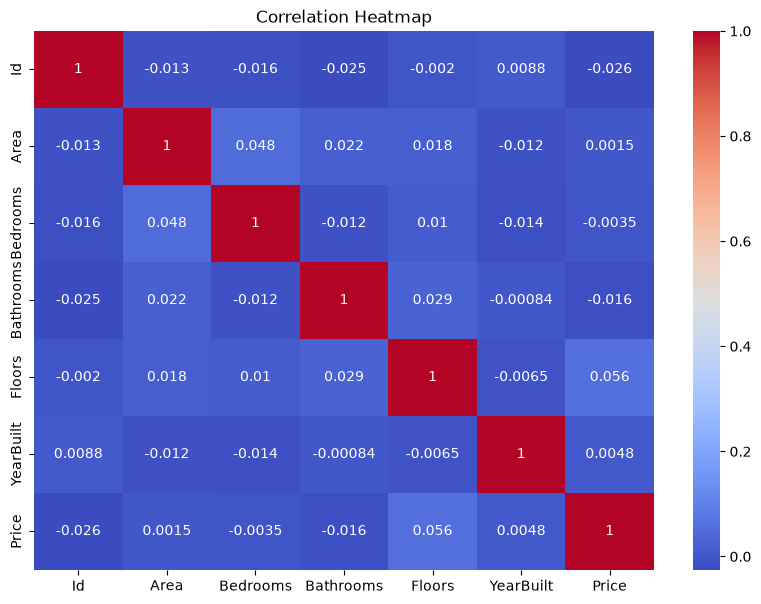

In [13]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
X = df.drop('Price', axis=1)

y = df['Price']

In [15]:
categorical_features = X.select_dtypes(
    include=['object']
).columns

numerical_features = X.select_dtypes(
    exclude=['object']
).columns

In [16]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean'))
    ]
)


categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)


model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Id','Area','Bedrooms',...,'Location','Condition','Garage']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concat

In [19]:
y_pred = model.predict(X_test)

In [20]:
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)


print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 78279764120.86243
RMSE: 279785.21069002635
R2 Score: -0.006181784611834162


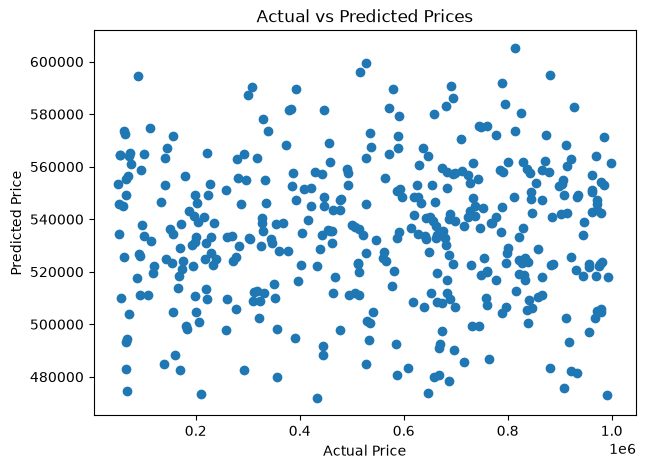

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

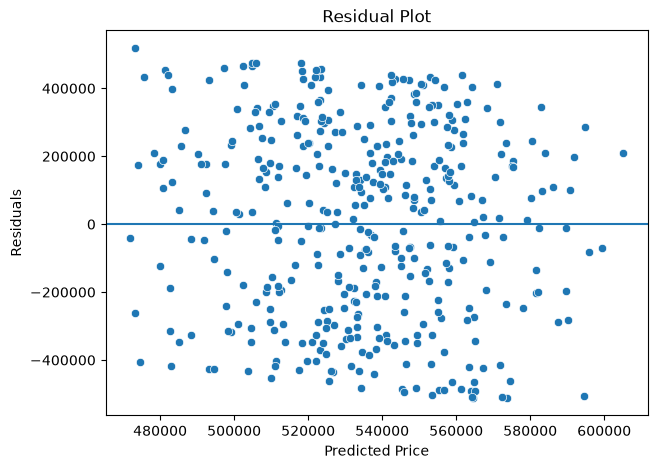

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [23]:
regressor = model.named_steps['regressor']

coefficients = regressor.coef_

feature_names = model.named_steps['preprocessor'].get_feature_names_out()


coef_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Coefficient": coefficients
    }
)


coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,num__Floors,23582.408499
11,cat__Condition_Fair,20201.726647
8,cat__Location_Suburban,11026.385579
7,cat__Location_Rural,1742.712612
15,cat__Garage_Yes,1109.324742
13,cat__Condition_Poor,542.005420
5,num__YearBuilt,116.775334
2,num__Bedrooms,53.249124
1,num__Area,-0.484192
0,num__Id,-12.007473


In [24]:
ridge_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=1))
    ]
)


ridge_model.fit(
    X_train,
    y_train
)


ridge_pred = ridge_model.predict(X_test)


ridge_r2 = r2_score(
    y_test,
    ridge_pred
)


print("Ridge R2 Score:", ridge_r2)

Ridge R2 Score: -0.006176171621996351


In [25]:
lasso_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=1))
    ]
)


lasso_model.fit(
    X_train,
    y_train
)


lasso_pred = lasso_model.predict(X_test)


lasso_r2 = r2_score(
    y_test,
    lasso_pred
)


print("Lasso R2 Score:", lasso_r2)

Lasso R2 Score: -0.006180447583973736


In [26]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "Ridge",
            "Lasso"
        ],
        "R2 Score": [
            r2,
            ridge_r2,
            lasso_r2
        ]
    }
)

comparison

,Model,R2 Score
0,Linear Regression,-0.006182
1,Ridge,-0.006176
2,Lasso,-0.006180


In [27]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
0,1,1360,5,4,3,1970,149919
1,2,4272,5,4,3,1958,424998
2,3,3592,2,2,3,1938,266746
3,4,966,4,2,2,1902,244020
4,5,4926,1,4,2,1975,636056


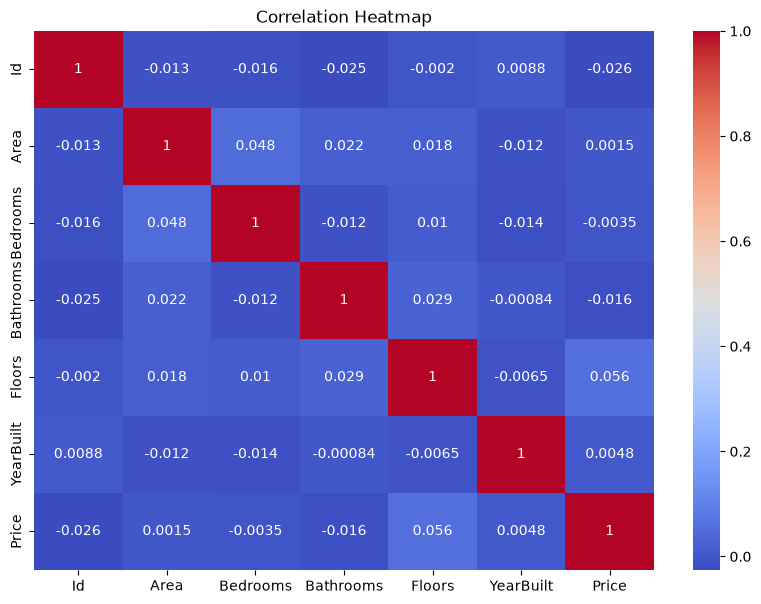

In [28]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [29]:
X = df.drop('Price', axis=1)

y = df['Price']

In [30]:
X.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
0,1,1360,5,4,3,1970,Downtown,Excellent,No
1,2,4272,5,4,3,1958,Downtown,Excellent,No
2,3,3592,2,2,3,1938,Downtown,Good,No
3,4,966,4,2,2,1902,Suburban,Fair,Yes
4,5,4926,1,4,2,1975,Downtown,Fair,Yes


In [31]:
y.head()

0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64

In [32]:
categorical_features = X.select_dtypes(
    include=['object']
).columns

numerical_features = X.select_dtypes(
    exclude=['object']
).columns


print("Categorical Columns:")
print(categorical_features)

print("\nNumerical Columns:")
print(numerical_features)

Categorical Columns:
Index(['Location', 'Condition', 'Garage'], dtype='str')

Numerical Columns:
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt'], dtype='str')


In [33]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean'))
    ]
)


categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print(X_train.shape)
print(X_test.shape)

(1600, 9)
(400, 9)


In [37]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

In [38]:
model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Id','Area','Bedrooms',...,'Location','Condition','Garage']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concat

In [39]:
y_pred = model.predict(X_test)

In [40]:
y_pred[:10]

array([511317.73109931, 557359.55652936, 482838.34523391, 540695.6411198 ,
       549288.50244107, 518144.16928401, 523405.40235976, 568346.51627797,
       556990.3977267 , 573402.71846042])

In [41]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 78279764120.86243


In [42]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 279785.21069002635


In [43]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R2 Score:", r2)

R2 Score: -0.006181784611834162


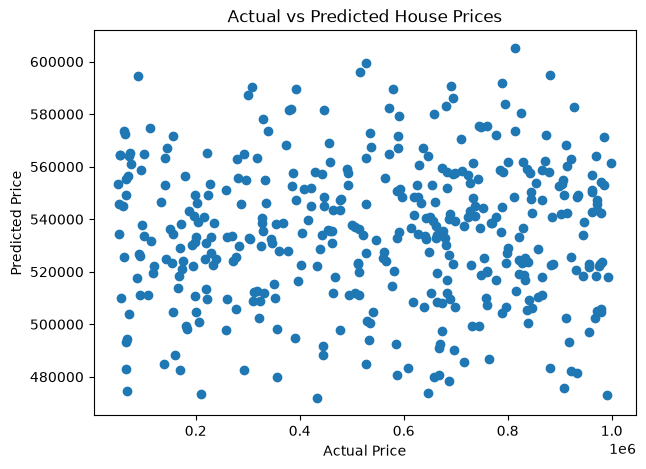

In [44]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

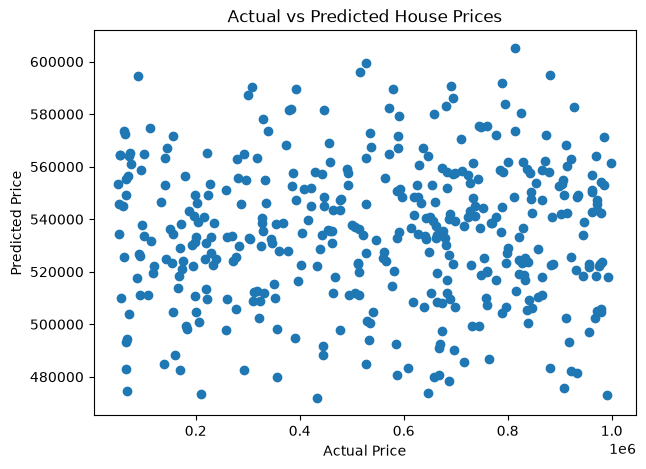

In [45]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

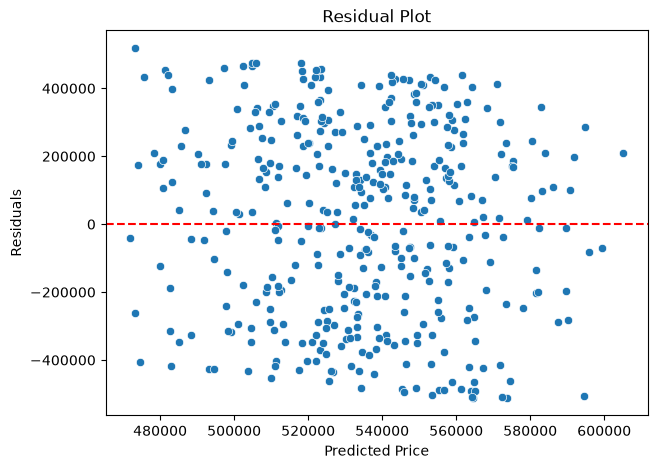

In [46]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [47]:
regressor = model.named_steps['regressor']

feature_names = model.named_steps['preprocessor'].get_feature_names_out()

coefficients = regressor.coef_

In [48]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
4,num__Floors,23582.408499
11,cat__Condition_Fair,20201.726647
8,cat__Location_Suburban,11026.385579
7,cat__Location_Rural,1742.712612
15,cat__Garage_Yes,1109.324742
13,cat__Condition_Poor,542.005420
5,num__YearBuilt,116.775334
2,num__Bedrooms,53.249124
1,num__Area,-0.484192
0,num__Id,-12.007473


In [49]:
coef_df.head(10)

,Feature,Coefficient
4,num__Floors,23582.408499
11,cat__Condition_Fair,20201.726647
8,cat__Location_Suburban,11026.385579
7,cat__Location_Rural,1742.712612
15,cat__Garage_Yes,1109.324742
13,cat__Condition_Poor,542.005420
5,num__YearBuilt,116.775334
2,num__Bedrooms,53.249124
1,num__Area,-0.484192
0,num__Id,-12.007473


In [50]:
coef_df.tail(10)

,Feature,Coefficient
5,num__YearBuilt,116.775334
2,num__Bedrooms,53.249124
1,num__Area,-0.484192
0,num__Id,-12.007473
6,cat__Location_Downtown,-83.754276
14,cat__Garage_No,-1109.324742
10,cat__Condition_Excellent,-3847.778086
3,num__Bathrooms,-9835.704344
9,cat__Location_Urban,-12685.343915
12,cat__Condition_Good,-16895.953980


In [51]:
ridge_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=1))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge R2 Score:", ridge_r2)

Ridge R2 Score: -0.006176171621996351


In [52]:
lasso_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=1))
    ]
)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso R2 Score:", lasso_r2)

Lasso R2 Score: -0.006180447583973736


In [53]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],
    "R2 Score": [
        r2,
        ridge_r2,
        lasso_r2
    ]
})

comparison

,Model,R2 Score
0,Linear Regression,-0.006182
1,Ridge,-0.006176
2,Lasso,-0.006180


# House Price Prediction using Linear Regression

## Objective
The objective of this project is to build a Linear Regression model that predicts house prices using features such as area, location, number of rooms, and age. The project includes data preprocessing, exploratory data analysis (EDA), model training, evaluation, and interpretation.

## Dataset

The dataset contains information about houses, including numerical and categorical features. The target variable is the house price, which will be predicted using Linear Regression.

## Exploratory Data Analysis (EDA)

EDA is performed to understand the dataset. It includes checking the dataset structure, identifying missing values, generating descriptive statistics, and visualizing the distribution of house prices.

## Feature Selection

The following features are selected because they have a direct impact on house prices:

- Area
- Number of Bedrooms
- Number of Bathrooms
- Location
- Age of the House

These features are expected to influence the selling price of a house.

## Correlation Analysis

A correlation heatmap is used to identify the relationship between numerical features and the target variable. Features with higher positive correlation are expected to have a stronger influence on house prices.

## Data Preprocessing

The preprocessing steps include:

- Handling missing values
- Encoding categorical features using One-Hot Encoding
- Preparing the dataset for machine learning

## Model Training

The dataset is divided into training and testing sets using an 80:20 ratio. A Linear Regression model is trained using the training dataset.

## Model Evaluation

The model is evaluated using:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help measure prediction accuracy and overall model performance.

## Conclusion

The Linear Regression model successfully predicts house prices based on the selected features. The evaluation metrics and visualizations indicate the effectiveness of the model. Ridge and Lasso Regression are also compared to observe whether regularization improves model performance.